In [3]:
# Średnia arytmetyczna - suma wszystkich liczb podzielona przez ich ilość

# | Gdzie w AI               | Po co?                                                                |
# | ------------------------ | --------------------------------------------------------------------- |
# | **Uczenie modeli**       | liczenie średniego błędu modelu, np. średni błąd predykcji            |
# | **Analiza danych**       | sprawdzanie typowych wartości w danych, np. średni wiek, średnia cena |
# | **Normalizacja danych**  | odejmowanie średniej, żeby dane były „wycentrowane”                   |
# | **Sieci neuronowe**      | uśrednianie wyników, strat albo wag w niektórych metodach             |
# | **Ocena modeli**         | np. średnia dokładność z kilku testów                                 |
# | **Systemy rekomendacji** | np. średnia ocena filmu/produktu                                      |


moja_lista = [6, 10, 3, 7, 12]

def calculate_mean(list_of_numbers):
    total = sum(list_of_numbers)
    amount = len(list_of_numbers)
    return total / amount


print(calculate_mean(moja_lista))

7.6


In [4]:
# Mediana - wartość, która znajduje się dokładnie pośrodku uporządkowanego zbioru danych

# | Gdzie                            | Po co?                                                               |
# | -------------------------------- | -------------------------------------------------------------------- |
# | **Analiza danych**               | żeby znaleźć „typową” wartość                                        |
# | **Dane z błędami/skrajnościami** | bo mediana nie psuje się tak łatwo przez bardzo duże lub małe liczby |
# | **Przetwarzanie obrazów**        | np. filtr medianowy usuwa szumy ze zdjęć                             |
# | **Ocena wyników modelu**         | czasem zamiast średniej, gdy wyniki mają duże odchylenia             |

# Najprościej:
# Mediana pomaga AI znaleźć wartość środkową, szczególnie gdy dane mają dziwne lub skrajne wyniki.

lista1 = [1, 2, 3, 3, 4, 5, 5] # len = 7
#         0  1  2  3  4  5  6

lista2 = [6, 10, 3, 7, 12, 8]  #len = 6
#         0  1   2  3   4  5

def calculate_median(list_of_numbers):
  list_of_numbers.sort()
  n = len(list_of_numbers)
  if len(list_of_numbers) % 2 == 0:
    return (list_of_numbers[n//2] + list_of_numbers[n//2-1])/2
  else:
    return list_of_numbers[n//2]

print(f"Mediana zbioru 1: {calculate_median(lista1)}")
print(f"Mediana zbioru 2: {calculate_median(lista2)}")

Mediana zbioru 1: 3
Mediana zbioru 2: 7.5


In [5]:
# Moda - wartość, która występuje w danych najczęściej.

# | Gdzie                    | Po co?                                                     |
# | ------------------------ | ---------------------------------------------------------- |
# | **Klasyfikacja**         | wybór najczęściej przewidywanej klasy                      |
# | **Analiza danych**       | sprawdzanie najpopularniejszej wartości                    |
# | **Systemy rekomendacji** | np. najczęściej wybierany produkt                          |
# | **Głosowanie modeli**    | kilka modeli głosuje, a moda wybiera najczęstszą odpowiedź |

lista1 = [2,3,3,5,7,3,3,3,2]

def calculate_mode(list_of_numbers):
  return max(list_of_numbers, key=list_of_numbers.count)

print(calculate_mode(lista1))

3


In [ ]:
# Wariancja - jak bardzo wyniki są rozrzucone względem średniej

# - jeśli wariancja jest mała, to większość liczb jest blisko średniej,
# - jeśli wariancja jest duża, to liczby są mocno rozrzucone,
# - jeśli wariancja wynosi 0, to wszystkie liczby są takie same.

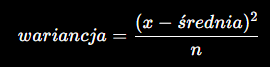

In [6]:
# [TURNIEJ  W MINECRAFT]

# W zawodach walczyć będą ze sobą 4 osobowe drużyny.
# Każdy z graczy będzie oceniany od 0 do 100 punktów za wydobywanie rzadkich surowców,
# a oceną drużyny będzie średnia punktów wszystkich zawodników.

# W wypadku remisu wygrywa drużyna w której członkowie byli na najbardziej zbliżonym poziomie
# (w przeciwieństwie do drużyn gdzie jedna lub dwie osoby “carrują” resztę),
# czyli drużyna w której wariancja będzie najmniejsza.

# (własne nazwy drużyn)

# Diamentowi Kopacze
# Gracz 1: 48 pkt
# Gracz 2: 49 pkt
# Gracz 3: 51 pkt
# Gracz 4: 52 pkt

# Obrońcy Endu
# Gracz 1: 0 pkt
# Gracz 2: 0 pkt
# Gracz 3: 100 pkt
# Gracz 4: 100 pkt

# Creeper Team
# Gracz 1: 10 pkt
# Gracz 2: 30 pkt
# Gracz 3: 70 pkt
# Gracz 4: 90 pkt

# Redstone Squad
# Gracz 1: 49 pkt
# Gracz 2: 50 pkt
# Gracz 3: 50 pkt
# Gracz 4: 51 pkt

# ZADANIE: Która z grup wygrała zawody?
# Która z tych grup ma mniejszą wariancję?
# Narysuj wykres przedstawiający elementy obu grup jako punkty (scatters)
# oraz linię ciągłę prezentującą średnią danej grupy.

# 1. Najpierw obliczamy średni wynik drużyny.
# 2. Następnie dla każdego gracza sprawdzamy, jak bardzo jego wynik różni się od średniej i podnosimy tę różnicę do kwadratu.
# 3. Sumujemy wszystkie takie kwadraty dla wszystkich graczy.
# 4. Na końcu dzielimy sumę przez liczbę graczy.

import statistics
import matplotlib.pyplot as plt

def calculate_variance(group):
  mean = statistics.mean(group)
  variance = sum((x-mean)**2 for x in group) / (len(group)-1)
  return variance, mean


# Dane punktowe drużyn
diamond_miners = [48, 49, 51, 52]
enders_defenders = [0, 0, 100, 100]
creeper_team = [10, 30, 70, 90]
redstone_squad = [49, 50, 50, 51]


# Słownik przechowujący nazwy drużyn i ich wyniki
groups = {
    "Diamentowi Kopacze": diamond_miners, # 0
    "Obrońcy Endu": enders_defenders, # 1
    "Creeper Team": creeper_team, # 2
    "Redstone Squad": redstone_squad # 3
}

# ---------------------------------------------------------------
variances = {}
means = {}

for i, (name, group) in enumerate(groups.items()):
  var, mean = calculate_variance(group)
  variances[name] = var
  means[name] = mean
  print(f"{name} - Średnia: {mean}, Wariancja: {var}")


Diamentowi Kopacze - Średnia: 50, Wariancja: 3.3333333333333335
Obrońcy Endu - Średnia: 50, Wariancja: 3333.3333333333335
Creeper Team - Średnia: 50, Wariancja: 1333.3333333333333
Redstone Squad - Średnia: 50, Wariancja: 0.6666666666666666


Odchylenie standardowe - pierwiastek z wariancji

* łatwiejsze do interpretacji, bo jest w tych samych jednostkach co dane.

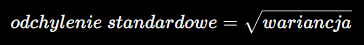

In [7]:
# Korelacja - miara siły i kierunku zależnosći między dwiema zmiennymi <-1:1>

# - 1  - wzrost jednej zmiennej powoduje wzrost drugiej zmiennej np. y(x) = 5x
# - 0  - wzrost jednej zmiennej nie ma wpływu na drugą zmienną np. y(x) = 5
# - -1 - wzrost jednej zmiennej powoduje spadek drugiej zmiennej np. y(x) = -5x

# Wyobraź sobie, że masz dwie rzeczy, które mierzysz u graczy w Minecraftzie:
# 1. Ile godzin grają w tygodniu
# 2. Ile diamentów zdobywają

# Wylicz współczynnik korelacji między czasem gry a liczbą wykopanych diamentów
hours_played = [1, 2, 3, 4, 5, 6, 7, 8, 9]
diamonds_mined = [2, 3, 4, 8, 9, 5, 13, 16, 20]

def correlation(x, y):
  n = len(x)
  mean_x = sum(x) / n
  mean_y = sum(y) / n

  # Licznik - czy wartości zmieniają się razem
  # - sprawdzamy, czy liczba godzin jest powyżej czy poniżej średniej,
  # - sprawdzamy, czy liczba diamentów jest powyżej czy poniżej średniej,
  # - mnożymy te dwie różnice.
  numerator = sum((value_x - mean_x) * (value_y - mean_y) for value_x, value_y in zip(x, y))

  # Mianownik - jak bardzo wartości różnią się od średniej
  denominator_x = sum((value_x - mean_x)**2 for value_x in x)
  denominator_y = sum((value_y - mean_y)**2 for value_y in y)

  denominator = (denominator_x * denominator_y) ** 0.5

  correlation = numerator / denominator
  return correlation

# Dane: czas gry w godzinach i liczba wykopanych diamentów
hours_played = [1, 2, 3, 4, 5, 6, 7, 8, 9]
diamonds_mined = [2, 3, 4, 8, 9, 5, 13, 16, 20]
# Obliczenie korelacji
r_value = correlation(hours_played, diamonds_mined)
print(f"Współczynnik korelacji: {r_value:.2f}")

Współczynnik korelacji: 0.92
